# **MÓDULO 32 - Exercício**
# Random Forest


Nesta tarefa, vocês vão trabalhar com uma base de dados de avaliações de vinhos, onde o objetivo é prever a pontuação dos vinhos usando o algoritmo de Random Forest para classificação multiclasse.

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import math
from sklearn.metrics import f1_score

In [2]:
df = pd.read_csv("winequality-red.csv", delimiter=',')

df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


**Vamos conhecer nossa base:**

Características dos Vinhos (Features)

Fixed Acidity: Acidez fixa do vinho.

Volatile Acidity: Acidez volátil do vinho.

Citric Acid: Quantidade de ácido cítrico no vinho.

Residual Sugar: Açúcar residual presente no vinho.

Chlorides: Nível de cloretos no vinho.

Free Sulfur Dioxide: Dióxido de enxofre livre no vinho.

Total Sulfur Dioxide: Quantidade total de dióxido de enxofre no vinho.

Density: Densidade do vinho.

pH: Nível de pH do vinho.

Sulphates: Quantidade de sulfatos no vinho.

Alcohol: Teor alcoólico do vinho.



**Variável de Saída (Target):**

Quality: Pontuação do vinho baseada em dados sensoriais, variando de 0 a 10.


Esta abordagem permitirá que vocês explorem como diferentes características químicas influenciam a qualidade dos vinhos e como o Random Forest pode ser usado para fazer previsões precisas com base nesses dados.

# 1 - Realize a primeira etapa de pré processamento dos dados.

A) Verifique os tipos de dados.


B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.

Primeiramente, realizou-se a inspeção das variáveis presentes na base de dados original, avaliando seus tipos e a consistência dos valores.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
df.isna().any().any()

np.False_

Nessa etapa inicial, observou-se que o conjunto de dados não apresenta registros nulos ou valores inválidos. Além disso, os tipos das variáveis estão definidos corretamente, indicando que a base está adequada para avançar para as próximas etapas de preparação e análise.


# 2 - Realize a segunda e terceita etapa de pré processamento dos dados.

A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.

B) Verifique o balanceamento da váriavel Target.

C)  Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.

D) Crie um novo dataframe apenas com as váriaveis que parecem ter maior correlação com a target. (Negativa ou positiva)


Portanto, na sequência, torna-se necessário investigar a presença de outliers e possíveis anomalias nos valores das variáveis.

In [5]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


De forma geral, ao observar o comportamento das variáveis por meio das estatísticas descritivas, nota-se que a maioria não apresenta indícios claros de comportamentos anômalos. No entanto, as variáveis free sulfur dioxide e total sulfur dioxide se destacam, pois seus valores máximos estão muito distantes tanto da média quanto da mediana do conjunto de dados, sugerindo a presença de valores extremos.

Diante desse comportamento, torna-se necessário aprofundar a verificação dessas duas variáveis para confirmar a existência de outliers e avaliar se esses registros correspondem a medições válidas ou a possíveis anomalias do processo de coleta. Para isso, será utilizado distribuições de dados através de boxplots.

In [6]:
variaveis = ['fixed acidity','volatile acidity','citric acid','residual sugar','chlorides','free sulfur dioxide','total sulfur dioxide','density','pH','sulphates','alcohol','quality']

n = len(variaveis)
ncols = 4
nrows = math.ceil(n/ncols)

fig = make_subplots(rows=nrows, cols=ncols, subplot_titles=variaveis)

for i in range(len(variaveis)):
    col = variaveis[i]
    r = (i//ncols) + 1
    c = (i % ncols) + 1
    fig.add_trace(go.Box(y=df[col], name=col, boxpoints='outliers', showlegend=False), row=r, col=c)

total = nrows*ncols
for k in range(n, total):
    r = (k//ncols) + 1
    c = (k % ncols) + 1
    fig.update_xaxes(visible=False, row=r, col=c)
    fig.update_yaxes(visible=False, row=r, col=c)

fig.update_layout(title='Boxplots das variaveis do dataset', height=300*nrows, width=380*ncols)
fig.show()

Após uma pesquisa a respeito de vinhos, nota-se que, embora algumas variáveis apresentem valores extremos, esses estão dentro de faixas plausíveis para um vinho e podem representar medições reais do processo de produção e de análise laboratorial. Como neste trabalho será utilizado o modelo de Random Forest, que tende a ser mais robusto e a lidar melhor com outliers por construir regras de decisão baseadas em partições do espaço de atributos, optou-se por manter a base sem tratamento específico para os outliers, preservando os dados originais para as etapas de modelagem.

Na sequência, torna-se necessário verificar o balanceamento da variável objetivo (quality), analisando a distribuição das classes e identificando possíveis desproporções que possam afetar o treinamento do modelo e a escolha de métricas de avaliação.

In [7]:
fig = px.histogram(df, x='quality')
fig.update_layout(title='Distribuição de Quality', xaxis_title='quality', yaxis_title='Quantidade')
fig.show()

Após plotar o histograma da variável quality, observa-se uma concentração majoritária de vinhos classificados como 5 e 6, seguida pelas classes 7, 4, 8 e 3. A baixa ocorrência das classes 3, 4 e 8, em conjunto com a predominância de 5 e 6, pode levar o modelo a apresentar viés em favor das classes mais frequentes, dificultando a correta identificação dos vinhos com qualidade mais baixa.

Ainda assim, considerando que o Random Forest é um algoritmo relativamente robusto e capaz de lidar melhor com distribuições desbalanceadas em comparação com modelos mais simples, optou-se por manter a distribuição original das classes nesta etapa e avaliar o comportamento do modelo inicialmente, utilizando métricas adequadas para refletir o desempenho em todas as classes.

Em seguida, será verificado a correlação das variáveis entre si para filtrar quais delas realmente devem ser usadas no modelo.

In [8]:
corr = df.corr(numeric_only=True)

fig = px.imshow(corr, color_continuous_scale='PiYG', text_auto='.2f', aspect='auto')
fig.update_layout(title='Matriz de correlação', xaxis_title='', yaxis_title='')
fig.show()

Olhando a matriz de correlação, percebe-se que a variável quality não apresenta correlações fortes com nenhuma das variáveis explicativas. A associação mais elevada ocorre com alcohol (≈ 0,48), indicando uma correlação positiva moderada. Em seguida, observa-se volatile acidity (≈ -0,39), com correlação negativa moderada.

Esse padrão sugere que a qualidade do vinho não depende de forma direta e isolada de uma única variável. Em vez disso, é provável que o resultado esteja relacionado à combinação de múltiplos fatores e a relações não lineares entre atributos. Porém como o exercício soliticitou criar um novo dataFrame com as variáveis de maior correlação, foram selecionadas as 5 variáveis de maior correlação com a qualidade.

In [9]:
corr = df.corr(numeric_only=True)['quality'].drop('quality')
corr = corr.abs().sort_values(ascending=False)
print(corr)

variaveis_corr = list(corr.head(5).index)

df_corr = df[variaveis_corr + ['quality']]
df_corr

alcohol                 0.476166
volatile acidity        0.390558
sulphates               0.251397
citric acid             0.226373
total sulfur dioxide    0.185100
density                 0.174919
chlorides               0.128907
fixed acidity           0.124052
pH                      0.057731
free sulfur dioxide     0.050656
residual sugar          0.013732
Name: quality, dtype: float64


,alcohol,volatile acidity,sulphates,citric acid,total sulfur dioxide,quality
0,9.4,0.700,0.56,0.00,34.0,5
1,9.8,0.880,0.68,0.00,67.0,5
2,9.8,0.760,0.65,0.04,54.0,5
3,9.8,0.280,0.58,0.56,60.0,6
4,9.4,0.700,0.56,0.00,34.0,5
...,...,...,...,...,...,...
1594,10.5,0.600,0.58,0.08,44.0,5
1595,11.2,0.550,0.76,0.10,51.0,6
1596,11.0,0.510,0.75,0.13,40.0,6
1597,10.2,0.645,0.71,0.12,44.0,5


# 3 - Preparação Final dos Dados

A) Separe a base em X(Features) e Y(Target)

B) Separe a base em treino e teste.


Na etapa final de preparação dos dados, serão realizadas duas divisões em conjuntos de treino e teste. Uma utilizando o dataframe original, contendo todas as variáveis do conjunto de dados, e outra utilizando o dataframe reduzido, composto apenas pelas variáveis selecionadas por apresentarem maior correlação com a variável alvo.

Essa comparação permite avaliar se a redução de atributos impacta o desempenho do modelo, verificando a diferença entre treinar o Random Forest com todas as variáveis disponíveis e treinar apenas com o subconjunto de maior correlação.

Além disso, devido ao desbalanceamento das classes da variável objetivo, optou-se por realizar uma divisão estratificada, utilizando o parâmetro stratify = df['quality']. Dessa forma, busca-se manter, tanto no conjunto de treino quanto no conjunto de teste, proporções de classes semelhantes às observadas no conjunto de dados original, reduzindo o risco de o modelo ser treinado ou avaliado com distribuições distorcidas.

In [10]:
x = df.drop('quality', axis=1)
y = df['quality']
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

In [11]:
x_corr = df_corr.drop('quality', axis=1)
x_corr_treino, x_corr_teste, y_corr_treino, y_corr_teste = train_test_split(x_corr, y, test_size=0.2, stratify=y, random_state=42)

Neste caso, utilizou-se a mesma variável y para ambas as divisões, pois, nos dois datasets, a variável objetivo é a mesma (quality). Além disso, manteve-se a mesma separação de treino e teste para os dois cenários, garantindo que a comparação entre o modelo treinado com o conjunto completo de atributos e o modelo treinado apenas com as variáveis selecionadas seja feita sobre os mesmos registros, de forma consistente.

# 4 - Modelagem e Avaliação

A) Inicie e treine o modelo de Random Forest

B) Aplique a base de teste o modelo.

C) Avalie as principais métricas da Claissificação e traga insights acerca do resultado, interprete os valores achados.

D) Você nota que o modelo teve dificuldade para prever alguma classe? Se sim, acredita que tenha relação com o balanceamento dos dados? Explique.

Primeiro iniciaremos o modelo de Random Forest com o dataframe completo e analisaremos seus resultados. Em seguida, iniciaremos o modelo para o dataframe das variáveis de maior correlação com a qualidade do vinho e compararemos os resultados obtidos.

In [12]:
random_forest = RandomForestClassifier(random_state=42)
random_forest.fit(x_treino, y_treino)

RandomForestClassifier(random_state=42)

In [13]:
y_pred = random_forest.predict(x_teste)

accuracy = accuracy_score(y_teste, y_pred)
report = classification_report(y_teste, y_pred)
conf_matrix = confusion_matrix(y_teste, y_pred)

print(f"Acurácia: {accuracy:.2f}")
print("Relatório de Classificação:\n", report)
labels = sorted(y_teste.unique())

fig = px.imshow(conf_matrix, x=labels, y=labels, text_auto=True, aspect='auto', color_continuous_scale='PiYG')
fig.update_layout(title='Matriz de Confusao', xaxis_title='Predito', yaxis_title='Real')
fig.show()

Acurácia: 0.68
Relatório de Classificação:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.76      0.73       136
           6       0.65      0.70      0.67       128
           7       0.71      0.55      0.62        40
           8       0.50      0.33      0.40         3

    accuracy                           0.68       320
   macro avg       0.43      0.39      0.40       320
weighted avg       0.65      0.68      0.66       320



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



Ao analisar as métricas do modelo, observa-se que o algoritmo obteve uma acurácia de 68%. Embora esse valor não seja necessariamente baixo, a análise da matriz de confusão evidencia que o modelo apresenta dificuldade em lidar com as classes menos frequentes, já que as classes 3, 4 e 8 estão sendo praticamente ignoradas, com poucos ou nenhum acerto.

Esse comportamento também é refletido no valor de f1 macro average, que ficou em aproximadamente 40%, indicando um desempenho fraco. A matriz de confusão sugere que a classe 4 é frequentemente confundida com as classes 5 e 6, enquanto a classe 7 é confundida principalmente com a classe 6. Além disso, quase não há predição para as classes 3 e 4, o que reforça a presença de um viés causado pelo desbalanceamento da variável objetivo, já que, pela baixa presença das classes raras, o modelo não consegue capturar tão bem o que define essas categorias.

Agora, repetiremos a criação do modelo para o conjunto de variáveis de maior correlação com a variável objetivo.

In [14]:
random_forest_corr = RandomForestClassifier(random_state=42)
random_forest_corr.fit(x_corr_treino, y_corr_treino)

RandomForestClassifier(random_state=42)

In [15]:
y_corr_pred = random_forest_corr.predict(x_corr_teste)

accuracy_corr = accuracy_score(y_corr_teste, y_corr_pred)
report_corr = classification_report(y_corr_teste, y_corr_pred)
conf_matrix_corr = confusion_matrix(y_corr_teste, y_corr_pred)

print(f"Acurácia: {accuracy_corr:.2f}")
print("Relatório de Classificação:\n", report_corr)
labels = sorted(y_corr_teste.unique())

fig = px.imshow(conf_matrix_corr, x=labels, y=labels, text_auto=True, aspect='auto', color_continuous_scale='PiYG')
fig.update_layout(title='Matriz de Confusao', xaxis_title='Predito', yaxis_title='Real')
fig.show()

Acurácia: 0.68
Relatório de Classificação:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.75      0.73       136
           6       0.64      0.72      0.68       128
           7       0.76      0.55      0.64        40
           8       0.50      0.33      0.40         3

    accuracy                           0.68       320
   macro avg       0.43      0.39      0.41       320
weighted avg       0.66      0.68      0.66       320



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



Para o modelo treinado com as variáveis de maior correlação, obteve-se um desempenho muito parecido com o modelo com todas as variáveis. A acurácia manteve-se em 68% e a f1 macro variou sutilmente, indicando que a seleção baseada na correlação linear não melhorou a capacidade do modelo em identificar as classes mais raras. Porém, pela semelhança dos resultados obtidos, o modelo reduzido parece ser capaz de representar o comportamento da variável quality tão bem quanto o original, mesmo utilizando menos variáveis.

A seguir será necessário tentar melhorar o desempenho obtido, modificando os hiperparâmetros da floresta.

# 5 - Melhorando os Hyperparametros

A) Defina o Grid de parametros que você quer testar

B) Inicie e Treine um novo modelo utilizando o random search.

C) Avalie os resultados do modelo.

D) Você identificou melhorias no modelo após aplicar o random search? Justifique.


ps. Essa parte da atividade demorará um pouco para rodar!

In [16]:
param_grid = {'n_estimators':[50,100,200],'max_depth':[None,10,20,30],'min_samples_split':[2,5,10],'min_samples_leaf':[1,2,4],'max_features':['sqrt','log2'],'class_weight':[None,'balanced']}

grid_search = GridSearchCV(estimator=random_forest, param_grid=param_grid, cv=5, scoring="f1_macro", n_jobs=-1)
grid_search.fit(x_treino, y_treino)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}
0.40939359297840294


In [17]:
random_forest = RandomForestClassifier(n_estimators=50, random_state=42, class_weight='balanced', max_depth=None, max_features='sqrt', min_samples_leaf=2, min_samples_split=5)
random_forest.fit(x_treino, y_treino)

y_pred = random_forest.predict(x_teste)

accuracy = accuracy_score(y_teste, y_pred)
report = classification_report(y_teste, y_pred)
conf_matrix = confusion_matrix(y_teste, y_pred)

print(f"Acurácia: {accuracy:.2f}")
print("Relatório de Classificação:\n", report)
labels = sorted(y_teste.unique())

fig = px.imshow(conf_matrix, x=labels, y=labels, text_auto=True, aspect='auto', color_continuous_scale='PiYG')
fig.update_layout(title='Matriz de Confusao', xaxis_title='Predito', yaxis_title='Real')
fig.show()

Acurácia: 0.66
Relatório de Classificação:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.72      0.77      0.74       136
           6       0.64      0.65      0.65       128
           7       0.57      0.57      0.57        40
           8       0.33      0.33      0.33         3

    accuracy                           0.66       320
   macro avg       0.38      0.39      0.38       320
weighted avg       0.64      0.66      0.65       320



Após o ajuste de hiperparâmetros via GridSearchCV, observou-se que o desempenho do modelo não apresentou melhora relevante. A acurácia permaneceu em torno de 66% e o f1 macro manteve-se próximo de 40%, porém com um sútil queda para 0,38. A matriz de confusão indica que as classes raras (3 e 4) continuam sendo praticamente ignoradas, reforçando que o principal fator limitante é o desbalanceamento e a baixa quantidade de amostras dessas classes, o que impede o modelo de aprender padrões representativos para essas categorias.

In [18]:
param_grid = {'n_estimators':[50,100,200],'max_depth':[None,10,20,30],'min_samples_split':[2,5,10],'min_samples_leaf':[1,2,4],'max_features':['sqrt','log2'],'class_weight':[None,'balanced']}

grid_search_corr = GridSearchCV(estimator=random_forest_corr, param_grid=param_grid, cv=5, scoring="f1_macro", n_jobs=-1)
grid_search_corr.fit(x_corr_treino, y_corr_treino)

print(grid_search_corr.best_params_)
print(grid_search_corr.best_score_)

{'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 50}
0.4088099653834677


In [19]:
random_forest_corr = RandomForestClassifier(n_estimators=50, random_state=42, class_weight='balanced', max_depth=10, max_features='sqrt', min_samples_leaf=4, min_samples_split=2)
random_forest_corr.fit(x_corr_treino, y_corr_treino)

y_corr_pred = random_forest_corr.predict(x_corr_teste)

accuracy_corr = accuracy_score(y_corr_teste, y_corr_pred)
report_corr = classification_report(y_corr_teste, y_corr_pred)
conf_matrix_corr = confusion_matrix(y_corr_teste, y_corr_pred)

print(f"Acurácia: {accuracy_corr:.2f}")
print("Relatório de Classificação:\n", report_corr)
labels = sorted(y_corr_teste.unique())

fig = px.imshow(conf_matrix_corr, x=labels, y=labels, text_auto=True, aspect='auto', color_continuous_scale='PiYG')
fig.update_layout(title='Matriz de Confusao', xaxis_title='Predito', yaxis_title='Real')
fig.show()

Acurácia: 0.61
Relatório de Classificação:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.21      0.27      0.24        11
           5       0.69      0.64      0.66       136
           6       0.61      0.60      0.61       128
           7       0.55      0.68      0.61        40
           8       0.33      0.33      0.33         3

    accuracy                           0.61       320
   macro avg       0.40      0.42      0.41       320
weighted avg       0.61      0.61      0.61       320



Para o modelo treinado com o conjunto reduzido de variáveis, observou-se uma redução na acurácia, que passou para 61%. Apesar disso, o f1 macro manteve-se em torno de 41%, indicando que o desempenho médio entre as classes permaneceu semelhante. Nota-se, no entanto, uma pequena melhora na identificação da classe 4 e um aumento no recall da classe 7, sugerindo que o modelo passou a reconhecer melhor algumas classes menos frequentes, ainda que com perda de desempenho nas classes majoritárias. Ainda assim, as classes 3 e 8 continuam com baixa capacidade de predição, reforçando que a baixa representatividade dessas categorias permanece como o principal fator limitante.

Como uma última análise, decidiu-se realizar a comparação entre as features de maior importância do modelo completo, incluindo todas as variáveis, e as variáveis selecionadas para o modelo simplificado.

alcohol                 0.145693
volatile acidity        0.130671
sulphates               0.125936
density                 0.096003
total sulfur dioxide    0.090790
pH                      0.079230
citric acid             0.076554
chlorides               0.071060
fixed acidity           0.062588
residual sugar          0.062181
free sulfur dioxide     0.059293
dtype: float64


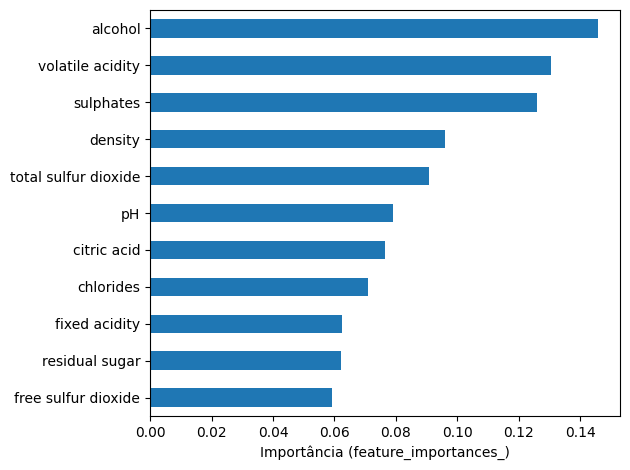

In [23]:

importancias = random_forest.feature_importances_

importancias_serie = pd.Series(importancias, index = x_treino.columns)
importancias_ordenadas = importancias_serie.sort_values(ascending = False)

print(importancias_ordenadas)

importancias_ordenadas.plot(kind='barh')
plt.gca().invert_yaxis()
plt.xlabel('Importância (feature_importances_)')
plt.tight_layout()
plt.show()


In [28]:
x_corr_treino.head(0)

,alcohol,volatile acidity,sulphates,citric acid,total sulfur dioxide


Através do modelo criado, as 5 variáveis de maior importância foram: alcohol, volatile acidity, sulphates, density e total sulfur dioxide. Porém, ao compararmos com as variáveis de maior correlação, é possível perceber que, em vez de utilizar citric acid, seria mais interessante incluir a densidade do vinho. Para comparar os resultados, será criado um novo modelo a fim de verificar se essa mudança afeta o desempenho obtido.

In [50]:
x_top = df[list(importancias_ordenadas.head(5).index)]

x_top_treino, x_top_teste, y_top_treino, y_top_teste = train_test_split(x_top, y, test_size = 0.2, stratify = y, random_state = 42)

param_grid = {'n_estimators' : [50, 100, 200], 'max_depth' : [None, 10, 20, 30], 'min_samples_split' : [2, 5, 10], 'min_samples_leaf' : [1, 2, 4], 'max_features' : ['sqrt', 'log2', None]}

random_forest_top = RandomForestClassifier(random_state = 42)
grid_search_top = GridSearchCV(estimator = random_forest_top, param_grid = param_grid, cv = 5, scoring = 'f1_macro')
grid_search_top.fit(x_top_treino, y_top_treino)

random_forest_top = grid_search_top.best_estimator_

y_top_pred = random_forest_top.predict(x_top_teste)

accuracy_top = accuracy_score(y_top_teste, y_top_pred)
report_top = classification_report(y_top_teste, y_top_pred)
conf_matrix_top = confusion_matrix(y_top_teste, y_top_pred)

print(f"Acurácia: {accuracy_top:.2f}")
print("Relatório de Classificação:\n", report_top)

labels = sorted(y_top_teste.unique())

fig = px.imshow(conf_matrix_top, x=labels, y=labels, text_auto=True, aspect='auto', color_continuous_scale='PiYG')
fig.update_layout(title='Matriz de Confusao (top 5 importancias)', xaxis_title='Predito', yaxis_title='Real')
fig.show()
comparacao = pd.DataFrame({'modelo' : ['top 5 corr', 'top 5 features'], 'features' : [', '.join(variaveis_corr), ', '.join(list(importancias_ordenadas.head(5).index))], 'acuracia' : [accuracy_corr, accuracy_top], 'f1_macro' : [f1_score(y_corr_teste, y_corr_pred, average='macro'), f1_score(y_top_teste, y_top_pred, average='macro')]})
comparacao


Acurácia: 0.68
Relatório de Classificação:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.75      0.73       136
           6       0.64      0.71      0.67       128
           7       0.70      0.57      0.63        40
           8       0.50      0.33      0.40         3

    accuracy                           0.68       320
   macro avg       0.43      0.39      0.41       320
weighted avg       0.65      0.68      0.66       320



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



,modelo,features,acuracia,f1_macro
0,top 5 corr,"alcohol, volatile acidity, sulphates, citric a...",0.609375,0.407995
1,top 5 features,"alcohol, volatile acidity, sulphates, density,...",0.678125,0.405899


Após analisar o resultado do modelo construído com as 5 variáveis mais importantes e comparar com o modelo baseado nas 5 variáveis de maior correlação com a variável objetivo, percebe-se uma alteração no valor da acurácia, que saiu de aproximadamente 61% para cerca de 68%, valor próximo ao encontrado no modelo completo. Porém, o valor de f1_macro permaneceu muito semelhante, em torno de 41%, o que ainda representa um desempenho baixo e insatisfatório. Isso indica que, mesmo utilizando variáveis com maior impacto para o modelo, ele ainda não consegue reproduzir o comportamento das classes mais raras com precisão.

# 6 - Chegando a perfeição

Baseado em tudo que você já aprendeu até agora, quais outras técnicas você acredita que poderiam ser aplicadas ao modelo para melhorar ainda mais suas previsões?

Com base nos resultados obtidos, pode-se afirmar que o desempenho do modelo foi impactado principalmente pelo desbalanceamento da variável objetivo e pela baixa representatividade das classes raras. Dessa forma, para buscar melhorias nas previsões, seria interessante aplicar estratégias de balanceamento no conjunto de treino, como oversampling das classes minoritárias ou undersampling das classes majoritárias.

Outra alternativa seria reagrupar a variável quality em categorias mais amplas. Como algumas classes possuem poucas amostras, reduzir o número de categorias pode tornar o problema mais viável e permitir que o modelo aprenda padrões mais consistentes.